# 03 — Functional Connectivity Analysis

This notebook converts the motion-censored 216-ROI resting-state
time series into functional connectivity matrices for Rest 1 and Rest 2.

For each session, censored time points are removed and pairwise Pearson
correlations are calculated across the 216 brain regions.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

ROI_DIR = Path(
    r"C:\Users\rahin\outputs\roi_timeseries_216"
)

roi_files = sorted(ROI_DIR.glob("*_216ROI.csv"))

print("ROI files found:", len(roi_files))
print("Expected:", 36)

ROI files found: 36
Expected: 36


## 1. Single-Session Functional Connectivity Test

A single session is tested first to verify that the censored ROI time series
can be converted into a 216 × 216 Pearson-correlation matrix.

In [4]:
TEST_FILE = ROI_DIR / "E3746_Rest1_216ROI.csv"

test_df = pd.read_csv(TEST_FILE)

print("Original shape:", test_df.shape)

# Remove censored TRs
test_clean = test_df.dropna(axis=0, how="all")

print("Usable time-series shape:", test_clean.shape)

# Functional connectivity matrix
test_fc = test_clean.corr(method="pearson")

print("Connectivity matrix shape:", test_fc.shape)

print(
    "Contains NaN values:",
    test_fc.isna().any().any()
)

print(
    "Symmetric:",
    np.allclose(
        test_fc.values,
        test_fc.values.T,
        equal_nan=True
    )
)

Original shape: (260, 216)
Usable time-series shape: (234, 216)
Connectivity matrix shape: (216, 216)
Contains NaN values: False
Symmetric: True


## 2. Batch Functional Connectivity Matrices

Pearson functional connectivity matrices are calculated for all Rest 1
and Rest 2 sessions after removing motion-censored time points.

In [6]:
FC_DIR = Path("outputs") / "functional_connectivity_216"
FC_DIR.mkdir(parents=True, exist_ok=True)

fc_summary = []

for roi_file in roi_files:

    # Load ROI time series
    df = pd.read_csv(roi_file)

    # Remove motion-censored TRs
    clean_df = df.dropna(axis=0, how="all")

    # Safety check
    if clean_df.shape[1] != 216:
        raise ValueError(
            f"{roi_file.name}: expected 216 ROIs, "
            f"found {clean_df.shape[1]}"
        )

    # Pearson functional connectivity
    fc = clean_df.corr(method="pearson")

    # Check matrix
    if fc.shape != (216, 216):
        raise ValueError(
            f"{roi_file.name}: unexpected FC shape {fc.shape}"
        )

    if fc.isna().any().any():
        raise ValueError(
            f"{roi_file.name}: FC contains NaN values"
        )

    if not np.allclose(fc.values, fc.values.T):
        raise ValueError(
            f"{roi_file.name}: FC matrix is not symmetric"
        )

    # Output filename
    output_name = roi_file.name.replace(
        "_216ROI.csv",
        "_FC_216.csv"
    )

    output_file = FC_DIR / output_name

    fc.to_csv(output_file)

    fc_summary.append({
        "Input": roi_file.name,
        "Usable_TRs": clean_df.shape[0],
        "FC_Rows": fc.shape[0],
        "FC_Columns": fc.shape[1],
        "Symmetric": True
    })

    print(
        f"{roi_file.stem} | "
        f"TRs={clean_df.shape[0]} | "
        f"FC={fc.shape} | OK"
    )


fc_summary_df = pd.DataFrame(fc_summary)

print("\nFUNCTIONAL CONNECTIVITY COMPLETE")
print("Matrices created:", len(fc_summary_df))

E3746_Rest1_216ROI | TRs=234 | FC=(216, 216) | OK
E3746_Rest2_216ROI | TRs=255 | FC=(216, 216) | OK
E3799_Rest1_216ROI | TRs=227 | FC=(216, 216) | OK
E3799_Rest2_216ROI | TRs=252 | FC=(216, 216) | OK
E3973_Rest1_216ROI | TRs=251 | FC=(216, 216) | OK
E3973_Rest2_216ROI | TRs=248 | FC=(216, 216) | OK
E4051_Rest1_216ROI | TRs=260 | FC=(216, 216) | OK
E4051_Rest2_216ROI | TRs=260 | FC=(216, 216) | OK
E4209_Rest1_216ROI | TRs=253 | FC=(216, 216) | OK
E4209_Rest2_216ROI | TRs=258 | FC=(216, 216) | OK
E4253_Rest1_216ROI | TRs=251 | FC=(216, 216) | OK
E4253_Rest2_216ROI | TRs=248 | FC=(216, 216) | OK
E4324_Rest1_216ROI | TRs=260 | FC=(216, 216) | OK
E4324_Rest2_216ROI | TRs=255 | FC=(216, 216) | OK
E4350_Rest1_216ROI | TRs=255 | FC=(216, 216) | OK
E4350_Rest2_216ROI | TRs=254 | FC=(216, 216) | OK
E4360_Rest1_216ROI | TRs=251 | FC=(216, 216) | OK
E4360_Rest2_216ROI | TRs=260 | FC=(216, 216) | OK
E4484_Rest1_216ROI | TRs=246 | FC=(216, 216) | OK
E4484_Rest2_216ROI | TRs=254 | FC=(216, 216) | OK


## 3. Pre-to-Post Functional Connectivity Change

For each participant, neurofeedback-related functional network
reorganization is represented as the difference between the post-
and pre-neurofeedback connectivity matrices:

\[
\Delta FC = FC_{Rest2} - FC_{Rest1}
\]

Positive values indicate increased functional connectivity from Rest 1
to Rest 2, whereas negative values indicate decreased connectivity.

In [8]:
# Test pre-to-post connectivity change on E3746

rest1_fc_file = FC_DIR / "E3746_Rest1_FC_216.csv"
rest2_fc_file = FC_DIR / "E3746_Rest2_FC_216.csv"

rest1_fc = pd.read_csv(
    rest1_fc_file,
    index_col=0
)

rest2_fc = pd.read_csv(
    rest2_fc_file,
    index_col=0
)

print("Rest1 FC shape:", rest1_fc.shape)
print("Rest2 FC shape:", rest2_fc.shape)

# Calculate connectivity change
delta_fc = rest2_fc - rest1_fc

print("Delta FC shape:", delta_fc.shape)

print(
    "Contains NaN:",
    delta_fc.isna().any().any()
)

print(
    "Symmetric:",
    np.allclose(
        delta_fc.values,
        delta_fc.values.T
    )
)

print(
    "Mean absolute connectivity change:",
    np.mean(np.abs(delta_fc.values))
)

Rest1 FC shape: (216, 216)
Rest2 FC shape: (216, 216)
Delta FC shape: (216, 216)
Contains NaN: False
Symmetric: True
Mean absolute connectivity change: 0.14895557354242978


### 3.1 Batch Pre-to-Post Connectivity Change

Pre-to-post functional connectivity change is calculated separately for
each participant. The mean absolute connectivity change provides a
subject-level summary of the magnitude of whole-brain network
reorganization.

In [10]:
DELTA_DIR = Path("outputs") / "delta_connectivity_216"
DELTA_DIR.mkdir(parents=True, exist_ok=True)

delta_summary = []

for subject in [
    "E3746","E3799","E3973","E4051","E4209","E4253",
    "E4324","E4350","E4360","E4484","E4689","E4697",
    "E4745","E5215","E5580","E5586","E5693","E5694"
]:

    rest1_file = FC_DIR / f"{subject}_Rest1_FC_216.csv"
    rest2_file = FC_DIR / f"{subject}_Rest2_FC_216.csv"

    rest1_fc = pd.read_csv(rest1_file, index_col=0)
    rest2_fc = pd.read_csv(rest2_file, index_col=0)

    # Pre-to-post change
    delta_fc = rest2_fc - rest1_fc

    # Save individual ΔFC matrix
    delta_file = DELTA_DIR / f"{subject}_DeltaFC_216.csv"
    delta_fc.to_csv(delta_file)

    # Exclude diagonal from summary metric
    delta_values = delta_fc.values.copy()

    np.fill_diagonal(
        delta_values,
        np.nan
    )

    mean_abs_delta = np.nanmean(
        np.abs(delta_values)
    )

    mean_signed_delta = np.nanmean(
        delta_values
    )

    delta_summary.append({
        "Subject": subject,
        "Mean_Absolute_DeltaFC": mean_abs_delta,
        "Mean_Signed_DeltaFC": mean_signed_delta
    })

    print(
        f"{subject} | "
        f"Mean |DeltaFC| = {mean_abs_delta:.4f} | "
        f"Mean DeltaFC = {mean_signed_delta:.4f}"
    )


delta_summary_df = pd.DataFrame(delta_summary)

print("\nDELTA CONNECTIVITY COMPLETE")
print("Participants:", len(delta_summary_df))

delta_summary_df

E3746 | Mean |DeltaFC| = 0.1496 | Mean DeltaFC = 0.0871
E3799 | Mean |DeltaFC| = 0.1999 | Mean DeltaFC = 0.1621
E3973 | Mean |DeltaFC| = 0.1084 | Mean DeltaFC = 0.0244
E4051 | Mean |DeltaFC| = 0.0915 | Mean DeltaFC = -0.0024
E4209 | Mean |DeltaFC| = 0.1899 | Mean DeltaFC = -0.1663
E4253 | Mean |DeltaFC| = 0.1522 | Mean DeltaFC = -0.1183
E4324 | Mean |DeltaFC| = 0.1228 | Mean DeltaFC = -0.0200
E4350 | Mean |DeltaFC| = 0.1142 | Mean DeltaFC = 0.0297
E4360 | Mean |DeltaFC| = 0.1254 | Mean DeltaFC = 0.0067
E4484 | Mean |DeltaFC| = 0.1490 | Mean DeltaFC = -0.0123
E4689 | Mean |DeltaFC| = 0.1700 | Mean DeltaFC = -0.0781
E4697 | Mean |DeltaFC| = 0.1321 | Mean DeltaFC = -0.0118
E4745 | Mean |DeltaFC| = 0.1347 | Mean DeltaFC = -0.0304
E5215 | Mean |DeltaFC| = 0.1222 | Mean DeltaFC = -0.0438
E5580 | Mean |DeltaFC| = 0.1088 | Mean DeltaFC = 0.0506
E5586 | Mean |DeltaFC| = 0.1620 | Mean DeltaFC = -0.0752
E5693 | Mean |DeltaFC| = 0.1613 | Mean DeltaFC = -0.1025
E5694 | Mean |DeltaFC| = 0.1189 | Mea

,Subject,Mean_Absolute_DeltaFC,Mean_Signed_DeltaFC
0,E3746,0.149648,0.087098
1,E3799,0.199888,0.162104
2,E3973,0.108394,0.024419
3,E4051,0.091465,-0.002424
4,E4209,0.189946,-0.166332
5,E4253,0.152174,-0.118265
6,E4324,0.122838,-0.020009
7,E4350,0.114232,0.029748
8,E4360,0.125433,0.006712
9,E4484,0.148959,-0.012294


## 4. Neurofeedback Group Comparison

Participant-level functional connectivity changes are linked with the
experimental treatment assignment to compare network reorganization
between the active neurofeedback and sham-control groups.

In [12]:
PARTICIPANTS_FILE = Path(
    r"C:\Neurofeedback_Data_Fall26\Imaging\Processed Rest1&2 Scans\participants.tsv"
)

participants = pd.read_csv(
    PARTICIPANTS_FILE,
    sep="\t"
)

# Keep relevant columns
group_info = participants[
    ["Exam", "Group"]
].copy()

# Normalize Exam IDs
group_info["Exam"] = (
    group_info["Exam"]
    .astype(str)
    .str.strip()
)

# One row per Exam ID
group_info = group_info.drop_duplicates(
    subset="Exam"
)

# Merge treatment group with DeltaFC results
delta_group_df = delta_summary_df.merge(
    group_info,
    left_on="Subject",
    right_on="Exam",
    how="left"
)

delta_group_df = delta_group_df[
    [
        "Subject",
        "Group",
        "Mean_Absolute_DeltaFC",
        "Mean_Signed_DeltaFC"
    ]
]

print("Participants:", len(delta_group_df))

print("\nMissing group labels:")
print(delta_group_df["Group"].isna().sum())

print("\nGroup counts:")
print(delta_group_df["Group"].value_counts())

print("\nGroup means:")
print(
    delta_group_df.groupby("Group")[
        ["Mean_Absolute_DeltaFC",
         "Mean_Signed_DeltaFC"]
    ].mean()
)

delta_group_df

Participants: 18

Missing group labels:
0

Group counts:
Group
active    10
sham       8
Name: count, dtype: int64

Group means:
        Mean_Absolute_DeltaFC  Mean_Signed_DeltaFC
Group                                             
active               0.144909            -0.000140
sham                 0.132986            -0.035223


,Subject,Group,Mean_Absolute_DeltaFC,Mean_Signed_DeltaFC
0,E3746,active,0.149648,0.087098
1,E3799,active,0.199888,0.162104
2,E3973,sham,0.108394,0.024419
3,E4051,sham,0.091465,-0.002424
4,E4209,sham,0.189946,-0.166332
5,E4253,sham,0.152174,-0.118265
6,E4324,active,0.122838,-0.020009
7,E4350,active,0.114232,0.029748
8,E4360,active,0.125433,0.006712
9,E4484,active,0.148959,-0.012294


### 4.1 Statistical Comparison of Network Reorganization

Differences in participant-level network reorganization between the
active and sham groups are evaluated using Welch's independent-samples
t-test, which does not assume equal group variances. Effect size is
also calculated to quantify the magnitude of the group difference.

In [14]:
from scipy.stats import ttest_ind
import numpy as np

active = delta_group_df[
    delta_group_df["Group"] == "active"
]["Mean_Absolute_DeltaFC"].values

sham = delta_group_df[
    delta_group_df["Group"] == "sham"
]["Mean_Absolute_DeltaFC"].values

# Welch's independent-samples t-test
t_stat, p_value = ttest_ind(
    active,
    sham,
    equal_var=False
)

# Descriptive statistics
active_mean = np.mean(active)
sham_mean = np.mean(sham)

active_sd = np.std(active, ddof=1)
sham_sd = np.std(sham, ddof=1)

# Pooled SD for Cohen's d
n1 = len(active)
n2 = len(sham)

pooled_sd = np.sqrt(
    (
        (n1 - 1) * active_sd**2 +
        (n2 - 1) * sham_sd**2
    )
    /
    (n1 + n2 - 2)
)

cohens_d = (
    active_mean - sham_mean
) / pooled_sd

print("ACTIVE")
print("n =", n1)
print("Mean =", round(active_mean, 4))
print("SD =", round(active_sd, 4))

print("\nSHAM")
print("n =", n2)
print("Mean =", round(sham_mean, 4))
print("SD =", round(sham_sd, 4))

print("\nGROUP COMPARISON")
print("Mean difference =", round(active_mean - sham_mean, 4))
print("Welch t =", round(t_stat, 4))
print("p =", round(p_value, 4))
print("Cohen's d =", round(cohens_d, 4))

ACTIVE
n = 10
Mean = 0.1449
SD = 0.0266

SHAM
n = 8
Mean = 0.133
SD = 0.0329

GROUP COMPARISON
Mean difference = 0.0119
Welch t = 0.8307
p = 0.4207
Cohen's d = 0.4038


### 4.2 Visualization of Individual Network Reorganization

Individual values are visualized to show the distribution and
between-subject variability in whole-brain functional connectivity
reorganization within the active and sham groups.

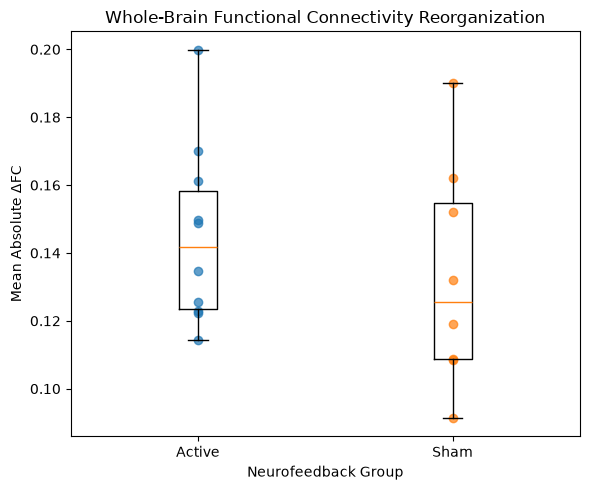

In [21]:
import matplotlib.pyplot as plt

active_values = delta_group_df[
    delta_group_df["Group"] == "active"
]["Mean_Absolute_DeltaFC"]

sham_values = delta_group_df[
    delta_group_df["Group"] == "sham"
]["Mean_Absolute_DeltaFC"]

plt.figure(figsize=(6, 5))

plt.boxplot(
    [active_values, sham_values],
    tick_labels=["Active", "Sham"]
)

# Add individual participant values
for i, values in enumerate(
    [active_values, sham_values],
    start=1
):
    plt.scatter(
        [i] * len(values),
        values,
        alpha=0.7
    )

plt.ylabel("Mean Absolute ΔFC")
plt.xlabel("Neurofeedback Group")

plt.title(
    "Whole-Brain Functional Connectivity Reorganization"
)

plt.tight_layout()
plt.show()

In [ ]:
%pip install matplotlib

## 5 — Fisher-Z Connectivity Matrices

For connection-level group analysis, Pearson correlation coefficients
are transformed using the Fisher r-to-z transformation. This improves
the statistical properties of correlation values for between-subject
comparisons.

The diagonal is excluded because self-correlations are equal to 1.

In [23]:
ZFC_DIR = Path("outputs") / "functional_connectivity_216_fisherz"
ZFC_DIR.mkdir(parents=True, exist_ok=True)

z_files_created = 0

for fc_file in sorted(FC_DIR.glob("*_FC_216.csv")):

    fc = pd.read_csv(
        fc_file,
        index_col=0
    )

    r = fc.to_numpy(dtype=float)

    # Prevent infinite values at exactly +1 or -1
    r = np.clip(
        r,
        -0.999999,
        0.999999
    )

    # Fisher r-to-z transformation
    z = np.arctanh(r)

    # Self-connections are not analyzed
    np.fill_diagonal(z, np.nan)

    z_df = pd.DataFrame(
        z,
        index=fc.index,
        columns=fc.columns
    )

    output_name = fc_file.name.replace(
        "_FC_216.csv",
        "_FC_Z_216.csv"
    )

    z_df.to_csv(
        ZFC_DIR / output_name
    )

    z_files_created += 1


print("Fisher-Z matrices created:", z_files_created)
print("Expected:", 36)
print("Output directory:", ZFC_DIR)

Fisher-Z matrices created: 36
Expected: 36
Output directory: outputs\functional_connectivity_216_fisherz


### 5.1 Fisher-Z Connectivity Change

For each participant, connectivity reorganization is calculated as the
difference between post-neurofeedback (Rest2) and pre-neurofeedback
(Rest1) Fisher-z connectivity matrices.

Group-average change matrices are then calculated separately for the
active and sham neurofeedback groups.

In [25]:
ZDELTA_DIR = Path("outputs") / "delta_connectivity_216_fisherz"
ZDELTA_DIR.mkdir(parents=True, exist_ok=True)

active_delta = []
sham_delta = []

for _, row in delta_group_df.iterrows():

    subject = row["Subject"]
    group = row["Group"]

    rest1_file = ZFC_DIR / f"{subject}_Rest1_FC_Z_216.csv"
    rest2_file = ZFC_DIR / f"{subject}_Rest2_FC_Z_216.csv"

    rest1 = pd.read_csv(rest1_file, index_col=0)
    rest2 = pd.read_csv(rest2_file, index_col=0)

    delta = rest2 - rest1

    # Save participant-level Fisher-Z change matrix
    delta.to_csv(
        ZDELTA_DIR / f"{subject}_DeltaFC_Z_216.csv"
    )

    if group == "active":
        active_delta.append(delta.to_numpy())

    elif group == "sham":
        sham_delta.append(delta.to_numpy())


active_delta = np.stack(active_delta)
sham_delta = np.stack(sham_delta)

active_mean_delta = np.nanmean(active_delta, axis=0)
sham_mean_delta = np.nanmean(sham_delta, axis=0)

group_difference = (
    active_mean_delta - sham_mean_delta
)

print("Active participants:", active_delta.shape[0])
print("Sham participants:", sham_delta.shape[0])

print("\nMatrix dimensions:")
print("Active:", active_mean_delta.shape)
print("Sham:", sham_mean_delta.shape)
print("Active - Sham:", group_difference.shape)

print("\nNaN values off diagonal:",
      np.isnan(group_difference[~np.eye(216, dtype=bool)]).sum())

print("Symmetric:",
      np.allclose(
          group_difference,
          group_difference.T,
          equal_nan=True
      ))

Active participants: 10
Sham participants: 8

Matrix dimensions:
Active: (216, 216)
Sham: (216, 216)
Active - Sham: (216, 216)

NaN values off diagonal: 0
Symmetric: True


C:\Users\rahin\AppData\Local\Temp\ipykernel_24508\1679044585.py:35: RuntimeWarning: Mean of empty slice
  active_mean_delta = np.nanmean(active_delta, axis=0)
C:\Users\rahin\AppData\Local\Temp\ipykernel_24508\1679044585.py:36: RuntimeWarning: Mean of empty slice
  sham_mean_delta = np.nanmean(sham_delta, axis=0)


### 5.2 Active-versus-Sham Connectivity Reorganization Map

The group-difference matrix represents the difference in mean
Fisher-z connectivity change between active and sham neurofeedback:

\[
\Delta Z_{\mathrm{Active}}-\Delta Z_{\mathrm{Sham}}
\]

Positive values indicate connections showing relatively greater
increases in connectivity in the active group, whereas negative values
indicate relatively greater increases in the sham group or decreases
in the active group.

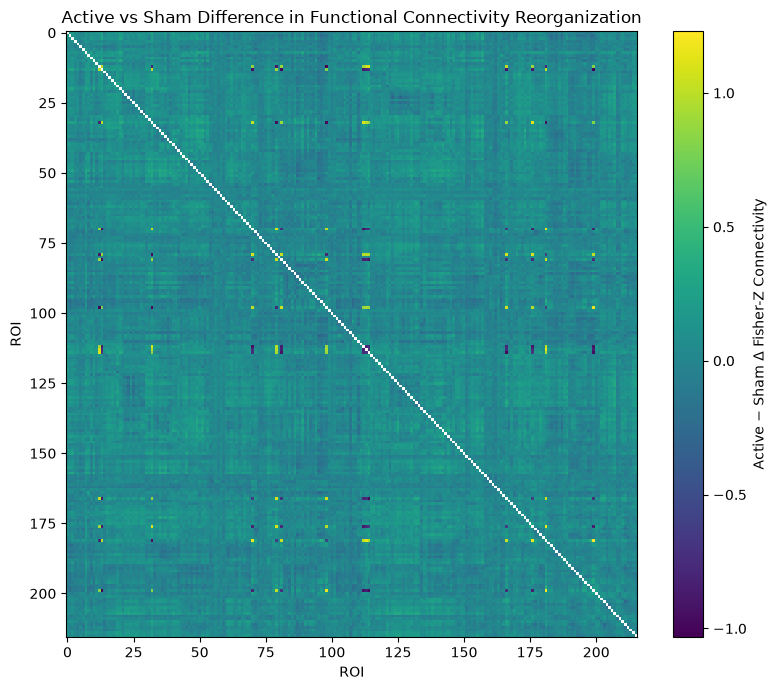

In [27]:
plt.figure(figsize=(8, 7))

plt.imshow(
    group_difference,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(
    label="Active − Sham Δ Fisher-Z Connectivity"
)

plt.xlabel("ROI")
plt.ylabel("ROI")

plt.title(
    "Active vs Sham Difference in Functional Connectivity Reorganization"
)

plt.tight_layout()
plt.show()

## 6 — Network-Level Connectivity Reorganization

The 216 ROI connectome is summarized into larger functional systems
to determine whether neurofeedback-related reorganization is
concentrated within or between specific brain networks.

In [29]:
from nilearn import datasets

schaefer_info = datasets.fetch_atlas_schaefer_2018(
    n_rois=200,
    yeo_networks=7,
    resolution_mm=2
)

print("Number of labels:", len(schaefer_info.labels))

print("\nFirst 20 labels:")
for i, label in enumerate(schaefer_info.labels[:20], start=1):
    print(i, label)

[fetch_atlas_schaefer_2018] Added README.md to C:\Users\rahin\nilearn_data
[fetch_atlas_schaefer_2018] Dataset created in C:\Users\rahin\nilearn_data\schaefer_2018
[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_7Networks_order.txt ...
[fetch_atlas_schaefer_2018]  ...done. (1 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_7Networks_order_FSLMNI152_2mm.nii.gz ...
[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

Number of labels: 201

First 20 labels:
1 Background
2 7Networks_LH_Vis_1
3 7Networks_LH_Vis_2
4 7Networks_LH_Vis_3
5 7Networks_LH_Vis_4
6 7Networks_LH_Vis

In [31]:
# Remove the background label
schaefer_labels = schaefer_info.labels[1:]

print("Cortical ROI labels:", len(schaefer_labels))

# Convert bytes to strings if necessary
schaefer_labels = [
    label.decode("utf-8") if isinstance(label, bytes) else str(label)
    for label in schaefer_labels
]

# Extract the Yeo-7 network name
schaefer_networks = []

for label in schaefer_labels:
    parts = label.split("_")
    network = parts[2]
    schaefer_networks.append(network)

# Add the 16 Tian subcortical ROIs as one Subcortical system
roi_networks = schaefer_networks + ["Subcortical"] * 16

print("Total ROI assignments:", len(roi_networks))

print("\nNetwork counts:")
print(pd.Series(roi_networks).value_counts())

Cortical ROI labels: 200
Total ROI assignments: 216

Network counts:
Default        46
SomMot         35
Cont           30
Vis            29
DorsAttn       26
SalVentAttn    22
Subcortical    16
Limbic         12
Name: count, dtype: int64


### 6.1 Network-Level Active-versus-Sham Reorganization

The ROI-level active-versus-sham difference matrix is summarized
according to the seven Schaefer cortical networks and one combined
subcortical system. Each matrix cell represents the mean Fisher-z
connectivity-change difference across all ROI pairs belonging to the
corresponding pair of systems.

In [33]:
network_order = [
    "Vis",
    "SomMot",
    "DorsAttn",
    "SalVentAttn",
    "Limbic",
    "Cont",
    "Default",
    "Subcortical"
]

roi_networks_array = np.array(roi_networks)

network_difference = pd.DataFrame(
    index=network_order,
    columns=network_order,
    dtype=float
)

for net1 in network_order:
    for net2 in network_order:

        idx1 = np.where(
            roi_networks_array == net1
        )[0]

        idx2 = np.where(
            roi_networks_array == net2
        )[0]

        block = group_difference[
            np.ix_(idx1, idx2)
        ]

        # For within-network blocks, avoid counting
        # diagonal self-connections.
        if net1 == net2:
            block = block.copy()

            if block.shape[0] == block.shape[1]:
                np.fill_diagonal(block, np.nan)

        network_difference.loc[
            net1, net2
        ] = np.nanmean(block)


print("Network matrix shape:",
      network_difference.shape)

print("\nActive - Sham mean ΔFisher-Z:")
display(network_difference.round(4))

Network matrix shape: (8, 8)

Active - Sham mean ΔFisher-Z:


,Vis,SomMot,DorsAttn,SalVentAttn,Limbic,Cont,Default,Subcortical
Vis,0.0650,0.0557,0.0546,0.0674,0.0076,0.0120,-0.0143,0.0381
SomMot,0.0557,0.0515,0.0936,0.0742,0.0215,0.0992,0.0473,0.0919
DorsAttn,0.0546,0.0936,0.0859,0.1421,0.0036,0.0873,0.0150,0.0934
SalVentAttn,0.0674,0.0742,0.1421,0.0797,0.0162,0.0725,-0.0031,0.0236
Limbic,0.0076,0.0215,0.0036,0.0162,-0.0346,0.0067,-0.0042,0.0017
Cont,0.0120,0.0992,0.0873,0.0725,0.0067,0.0577,0.0172,0.0493
Default,-0.0143,0.0473,0.0150,-0.0031,-0.0042,0.0172,0.0206,0.0213
Subcortical,0.0381,0.0919,0.0934,0.0236,0.0017,0.0493,0.0213,0.0234


### 6.2 Participant-Level Dorsal Attention–Salience/Ventral Attention Change

The dorsal attention–salience/ventral attention connection showed the
largest descriptive active-versus-sham difference. Participant-level
network-pair changes are therefore extracted to examine the
distribution of this effect across individuals.

In [35]:
dors_idx = np.where(
    roi_networks_array == "DorsAttn"
)[0]

sal_idx = np.where(
    roi_networks_array == "SalVentAttn"
)[0]

network_subject_results = []

for _, row in delta_group_df.iterrows():

    subject = row["Subject"]
    group = row["Group"]

    delta_file = (
        ZDELTA_DIR /
        f"{subject}_DeltaFC_Z_216.csv"
    )

    delta = pd.read_csv(
        delta_file,
        index_col=0
    ).to_numpy()

    block = delta[
        np.ix_(dors_idx, sal_idx)
    ]

    mean_change = np.nanmean(block)

    network_subject_results.append({
        "Subject": subject,
        "Group": group,
        "DorsAttn_SalVentAttn_DeltaZ": mean_change
    })


network_subject_df = pd.DataFrame(
    network_subject_results
)

print(
    network_subject_df.groupby("Group")[
        "DorsAttn_SalVentAttn_DeltaZ"
    ].agg(["count", "mean", "std"])
)

display(network_subject_df)

        count      mean       std
Group                            
active     10  0.066721  0.108337
sham        8 -0.075337  0.116374


,Subject,Group,DorsAttn_SalVentAttn_DeltaZ
0,E3746,active,0.183512
1,E3799,active,0.293465
2,E3973,sham,0.041887
3,E4051,sham,-0.042496
4,E4209,sham,-0.190455
5,E4253,sham,-0.101397
6,E4324,active,0.022035
7,E4350,active,-0.010580
8,E4360,active,0.066373
9,E4484,active,0.120443


In [37]:
from scipy.stats import ttest_ind
import numpy as np

active_net = network_subject_df[
    network_subject_df["Group"] == "active"
]["DorsAttn_SalVentAttn_DeltaZ"].values

sham_net = network_subject_df[
    network_subject_df["Group"] == "sham"
]["DorsAttn_SalVentAttn_DeltaZ"].values

# Welch's t-test
t_stat, p_value = ttest_ind(
    active_net,
    sham_net,
    equal_var=False
)

# Cohen's d
n1 = len(active_net)
n2 = len(sham_net)

sd1 = np.std(active_net, ddof=1)
sd2 = np.std(sham_net, ddof=1)

pooled_sd = np.sqrt(
    ((n1 - 1) * sd1**2 +
     (n2 - 1) * sd2**2)
    /
    (n1 + n2 - 2)
)

cohens_d = (
    np.mean(active_net) -
    np.mean(sham_net)
) / pooled_sd

print("Active mean:", round(np.mean(active_net), 4))
print("Sham mean:", round(np.mean(sham_net), 4))
print("Mean difference:", round(
    np.mean(active_net) - np.mean(sham_net), 4
))

print("\nWelch t:", round(t_stat, 4))
print("p:", round(p_value, 4))
print("Cohen's d:", round(cohens_d, 4))

Active mean: 0.0667
Sham mean: -0.0753
Mean difference: 0.1421

Welch t: 2.6533
p: 0.0184
Cohen's d: 1.2692


### 6.3 Multiple-Comparison-Aware Network Analysis

To avoid selecting network pairs based only on the largest observed
group difference, all unique within- and between-network connectivity
changes are evaluated systematically. Statistical significance is
subsequently assessed after correction for multiple comparisons.

In [43]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
from itertools import combinations_with_replacement

network_test_results = []

# Test all 36 unique within/between-network pairs
for net1, net2 in combinations_with_replacement(network_order, 2):

    idx1 = np.where(roi_networks_array == net1)[0]
    idx2 = np.where(roi_networks_array == net2)[0]

    active_values = []
    sham_values = []

    # Active participants
    for delta in active_delta:

        block = delta[np.ix_(idx1, idx2)].copy()

        # Remove self-connections for within-network comparisons
        if net1 == net2:
            np.fill_diagonal(block, np.nan)

        active_values.append(
            np.nanmean(block)
        )

    # Sham participants
    for delta in sham_delta:

        block = delta[np.ix_(idx1, idx2)].copy()

        if net1 == net2:
            np.fill_diagonal(block, np.nan)

        sham_values.append(
            np.nanmean(block)
        )

    active_values = np.array(active_values)
    sham_values = np.array(sham_values)

    # Welch t-test
    t_stat, p_value = ttest_ind(
        active_values,
        sham_values,
        equal_var=False
    )

    # Cohen's d
    n1 = len(active_values)
    n2 = len(sham_values)

    sd1 = np.std(active_values, ddof=1)
    sd2 = np.std(sham_values, ddof=1)

    pooled_sd = np.sqrt(
        (
            (n1 - 1) * sd1**2 +
            (n2 - 1) * sd2**2
        )
        /
        (n1 + n2 - 2)
    )

    d = (
        np.mean(active_values) -
        np.mean(sham_values)
    ) / pooled_sd

    network_test_results.append({
        "Network_1": net1,
        "Network_2": net2,
        "Active_Mean": np.mean(active_values),
        "Sham_Mean": np.mean(sham_values),
        "Difference": (
            np.mean(active_values) -
            np.mean(sham_values)
        ),
        "t": t_stat,
        "p_uncorrected": p_value,
        "Cohens_d": d
    })


network_stats_df = pd.DataFrame(
    network_test_results
)

# Benjamini-Hochberg FDR correction across 36 tests
reject, p_fdr, _, _ = multipletests(
    network_stats_df["p_uncorrected"],
    alpha=0.05,
    method="fdr_bh"
)

network_stats_df["p_FDR"] = p_fdr
network_stats_df["FDR_significant"] = reject

# Sort by uncorrected p-value
network_stats_df = network_stats_df.sort_values(
    "p_uncorrected"
).reset_index(drop=True)

print("Network comparisons:", len(network_stats_df))

print(
    "Uncorrected p < .05:",
    (network_stats_df["p_uncorrected"] < 0.05).sum()
)

print(
    "FDR-significant:",
    network_stats_df["FDR_significant"].sum()
)

display(
    network_stats_df.head(10).round(4)
)

Network comparisons: 36
Uncorrected p < .05: 3
FDR-significant: 0


,Network_1,Network_2,Active_Mean,Sham_Mean,Difference,t,p_uncorrected,Cohens_d,p_FDR,FDR_significant
0,DorsAttn,SalVentAttn,0.0667,-0.0753,0.1421,2.6533,0.0184,1.2692,0.4529,False
1,SomMot,Subcortical,0.0506,-0.0413,0.0919,2.3458,0.0346,1.1364,0.4529,False
2,DorsAttn,Subcortical,0.0398,-0.0536,0.0934,2.3500,0.0395,1.1849,0.4529,False
3,SomMot,Cont,0.0361,-0.0632,0.0992,2.1194,0.0503,0.9644,0.4529,False
4,DorsAttn,Cont,0.0295,-0.0578,0.0873,1.8138,0.0887,0.8458,0.6384,False
5,SalVentAttn,SalVentAttn,0.0465,-0.0332,0.0797,1.6495,0.1191,0.7756,0.7107,False
6,SomMot,SalVentAttn,0.0393,-0.0349,0.0742,1.4373,0.1729,0.6949,0.7107,False
7,SalVentAttn,Cont,0.0202,-0.0523,0.0725,1.4044,0.1798,0.6365,0.7107,False
8,DorsAttn,DorsAttn,0.0237,-0.0622,0.0859,1.3684,0.1913,0.6503,0.7107,False
9,Vis,SalVentAttn,0.0317,-0.0357,0.0674,1.3399,0.2015,0.6456,0.7107,False


In [41]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.9/11.3 MB 15.0 MB/s eta 0:00:01
   -------------------------------- ------- 9.2/11.3 MB 23.5 MB/s eta 0:00:01
   ---------------------------------------- 11.3/11.3 MB 22.8 MB/s  0:00:00

   ---------------------------------------- 0/6 [wrapt]
   ---------------------------------------- 0/6 [wrapt]
   ---------------------------------------- 0/6 [wrapt]
   ---------------------------------------- 0/6 [wrapt]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------ --------------------------------- 1/6 [patsy]
   ------------- --------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\rahin\OneDrive\Desktop\TU\Summer 2026\Brain fmri in R\Selim code\gnn_env\Scripts\python.exe -m pip install --upgrade pip
